In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from tensorflow.keras.models import Model

2025-04-15 11:50:00.564333: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744707000.631765   11713 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744707000.652682   11713 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744707000.706024   11713 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744707000.706076   11713 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744707000.706086   11713 computation_placer.cc:177] computation placer alr

In [2]:
# Loading The Data
(x_train, _), (x_test, _) = mnist.load_data()

In [3]:

# Reshape The Data
x_train = x_train.reshape(x_train.shape[0] , x_train.shape[1] , x_train.shape[2] , 1)
x_test = x_test.reshape(x_test.shape[0] , x_test.shape[1] , x_test.shape[2] , 1)


In [4]:
# Standarize The Data
x_train = x_train / 255
x_test  = x_test / 255

In [5]:
# Function to display The Data

def display_data(data , height, width, title):
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(data[i].reshape((height,width)))
        plt.gray()        
    plt.suptitle(title)

In [6]:
# Our Convolution AutoEncoder    
def Conv_AutoEncoder() :
    #Input Layer
    input_layer = Input(shape=(28, 28, 1), name="input_layer")
    # Encoder    
    x = Conv2D(16, (3, 3), activation='relu')(input_layer)
    x = MaxPooling2D((2, 2) , strides=(2,2))(x)
    x = Conv2D(8, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2) , strides=(2,2) , name = 'code_layer')(x)
    # Code - Bottle neck
    code = x
    # Decoder
    x = UpSampling2D((2, 2))(code)
    x = Conv2DTranspose(8, (3, 3), activation='relu')(x)
    x = UpSampling2D((2, 2) )(x)
    x = Conv2DTranspose(16, (3, 3), activation='relu')(x)
    # Output Layer
    output_layer = Conv2DTranspose(1, (3, 3), activation='sigmoid')(x)
    
    conv_Autoencoder = Model(input_layer , output_layer)
    
    return conv_Autoencoder

In [7]:
# Compiling The Model

Convolution_AutoEncoder = Conv_AutoEncoder()
Convolution_AutoEncoder.compile(optimizer='adam', loss='mse')
Convolution_AutoEncoder.summary()

2025-04-15 11:55:07.986722: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ code_layer (MaxPooling2D)       │ (None, 5, 5, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 12, 12, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 26, 26, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           145 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:

# Training The Model
Convolution_AutoEncoder.fit(x_train , x_train , epochs=10 ,
                            batch_size=32 , shuffle=True , 
                            validation_data=(x_test , x_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 38ms/step - loss: 0.0372 - val_loss: 0.0080
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - loss: 0.0076 - val_loss: 0.0062
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - loss: 0.0056 - val_loss: 0.0051
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - loss: 0.0052 - val_loss: 0.0048
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - loss: 0.0049 - val_loss: 0.0047
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - loss: 0.0045 - val_loss: 0.0043


In [9]:

# get The Decoded Data
decoded_data = Convolution_AutoEncoder.predict(x_test)

Encoder = Model(inputs = Convolution_AutoEncoder.input , outputs = Convolution_AutoEncoder.get_layer("code_layer").output)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step


In [10]:
# get The Encoded Data
encoded_data = Encoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step 


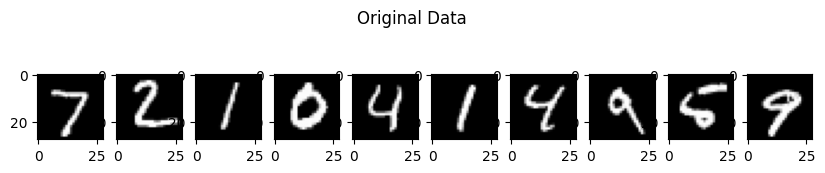

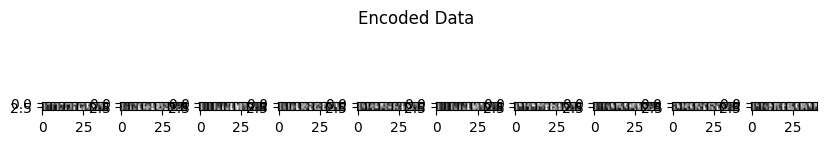

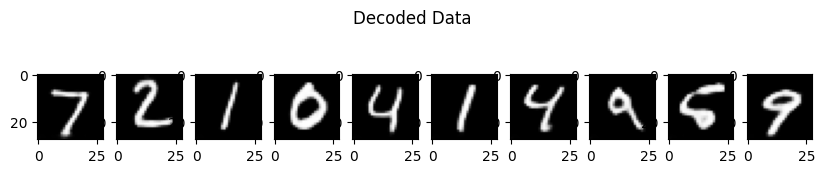

In [11]:
# display The Result

display_data(x_test , height = 28 , width = 28 , title = 'Original Data')
display_data(encoded_data , height = 5 , width = 5*8 , title = 'Encoded Data')
display_data(decoded_data , height = 28 , width = 28 , title = 'Decoded Data')    